In [2]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

# 1. Set random seed
seed = 22
tf.random.set_seed(seed)
np.random.seed(seed)

def debug_data_distribution(X_train, y_train, X_val, y_val, X_test, y_test):
    """Debug function to check data distribution and potential issues."""
    print("\n" + "="*60)
    print("DATA DISTRIBUTION ANALYSIS")
    print("="*60)

    # Class distribution
    print("Class distribution:")
    print(f"Train: {dict(zip(*np.unique(y_train, return_counts=True)))}")
    print(f"Val:   {dict(zip(*np.unique(y_val, return_counts=True)))}")
    print(f"Test:  {dict(zip(*np.unique(y_test, return_counts=True)))}")

    # Value ranges
    print(f"\nData value ranges:")
    print(f"Train: min={X_train.min():.4f}, max={X_train.max():.4f}, mean={X_train.mean():.4f}")
    print(f"Val:   min={X_val.min():.4f}, max={X_val.max():.4f}, mean={X_val.mean():.4f}")
    print(f"Test:  min={X_test.min():.4f}, max={X_test.max():.4f}, mean={X_test.mean():.4f}")

    # Shapes
    print(f"\nData shapes:")
    print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

    # Mean activations
    train_mean = X_train.mean(axis=(1,2,3))
    val_mean = X_val.mean(axis=(1,2,3))
    print(f"\nMean activation per sample:")
    print(f"Train mean: {train_mean.mean():.4f} ± {train_mean.std():.4f}")
    print(f"Val mean:   {val_mean.mean():.4f} ± {val_mean.std():.4f}")

    # Warnings
    if len(np.unique(y_val)) != len(np.unique(y_train)):
        print("⚠️ WARNING: Validation set doesn't contain all classes!")

    if X_val.std() == 0 or X_train.std() == 0:
        print("⚠️ WARNING: Zero std detected - check your data!")

    if abs(X_train.mean() - X_val.mean()) > 0.5:
        print("⚠️ WARNING: Large mean difference between train/val sets!")

    print("="*60)

def create_balanced_dataset(shape_input, file,
                           values_name, labels_name):
    """
    Load dataset and balance classes.
    balance_strategy = 'undersample' or 'oversample'
    """
    if len(shape_input) == 3:
        height, width, channels = shape_input
    elif len(shape_input) == 2:
        height, width = shape_input
        channels = 1
    else:
        raise ValueError("Shape Input must be (h, w) or (h, w, c).")

    # Load
    dataset = np.load(file)
    samples = dataset[values_name][:, :height, :width]
    classes = dataset[labels_name].astype(int)
    unique_classes = np.unique(classes)

    print(f"Original dataset: {samples.shape}, classes: {unique_classes}")
    print(f"Original class distribution: {dict(zip(*np.unique(classes, return_counts=True)))}")
    # Split
    X_temp, X_test, y_temp, y_test = train_test_split(
        samples, classes, test_size=0.2, stratify=classes, random_state=seed
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=seed
    )

    if channels == 1:
        X_train = np.expand_dims(X_train, -1)
        X_val = np.expand_dims(X_val, -1)
        X_test = np.expand_dims(X_test, -1)

    # Debug
    debug_data_distribution(X_train, y_train, X_val, y_val, X_test, y_test)

    return X_train, y_train, X_val, y_val, X_test, y_test, len(unique_classes)

# === Example usage ===
shape_input = (40, 40, 1)
X_train, y_train, X_val, y_val, X_test, y_test, n_classes = create_balanced_dataset(
    shape_input, "dataset_kws_multi.npz", 'features', 'labels'
)
class_names=['no', 'up', 'down', 'unknown', 'yes']
print("Classes Number: ", len(class_names))
print("Names: ", class_names)

#teacher_dvec_model = tf.keras.models.load_model("./models/teacher_sv_cnn_model.h5")
teacher_dvec_model = tf.keras.models.load_model("kws_multi_cnn_model.h5")
teacher_dvec_model.summary()


Original dataset: (27583, 40, 40), classes: [0 1 2 3 4]
Original class distribution: {np.int64(0): np.int64(3929), np.int64(1): np.int64(3715), np.int64(2): np.int64(3908), np.int64(3): np.int64(11994), np.int64(4): np.int64(4037)}

DATA DISTRIBUTION ANALYSIS
Class distribution:
Train: {np.int64(0): np.int64(2357), np.int64(1): np.int64(2229), np.int64(2): np.int64(2345), np.int64(3): np.int64(7196), np.int64(4): np.int64(2422)}
Val:   {np.int64(0): np.int64(786), np.int64(1): np.int64(743), np.int64(2): np.int64(781), np.int64(3): np.int64(2399), np.int64(4): np.int64(808)}
Test:  {np.int64(0): np.int64(786), np.int64(1): np.int64(743), np.int64(2): np.int64(782), np.int64(3): np.int64(2399), np.int64(4): np.int64(807)}

Data value ranges:
Train: min=0.0000, max=1.0000, mean=0.2987
Val:   min=0.0000, max=1.0000, mean=0.2994
Test:  min=0.0000, max=1.0000, mean=0.2991

Data shapes:
Train: (16549, 40, 40, 1), Val: (5517, 40, 40, 1), Test: (5517, 40, 40, 1)

Mean activation per sample:
Tr

Model: "teacher_kws_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 40, 40, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 40, 40, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 40, 40, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_36 (ReLU)                 │ (None, 40, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 20, 20, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 20, 20, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 20, 20, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 20, 20, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_37 (ReLU)                 │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 10, 10, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 10, 10, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_38 (ReLU)                 │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 256)            │       819,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_39 (ReLU)                 │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 128)            │           51

 Total params: 955,623 (3.65 MB)

 Trainable params: 954,277 (3.64 MB)

 Non-trainable params: 1,344 (5.25 KB)

 Optimizer params: 2 (12.00 B)


Student Model (Target Simple Dense Network):


Model: "student_dnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       409,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 542,725 (2.07 MB)

 Trainable params: 542,725 (2.07 MB)

 Non-trainable params: 0 (0.00 B)


COMPRESSING COMPLEX MODEL TO SIMPLE DENSE NETWORK
Teacher: Sparse Conv Model (955,621 params)
Student: Simple Dense Model (542,725 params)
Compression Ratio: 1.8x
Epoch 1/100
518/518 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.4881 - distill_loss: 0.0033 - f1_score: 0.4505 - student_loss: 1.3974 - total_loss: 0.3455 - val_accuracy: 0.6011 - val_distill_loss: 0.0022 - val_f1_score: 0.5722 - val_student_loss: 1.3176 - val_total_loss: 0.3069 - learning_rate: 0.0020
Epoch 2/100
518/518 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5976 - distill_loss: 0.0028 - f1_score: 0.5732 - student_loss: 1.2577 - total_loss: 0.3085 - val_accuracy: 0.6667 - val_distill_loss: 0.0019 - val_f1_score: 0.6314 - val_student_loss: 1.2340 - val_total_loss: 0.2856 - learning_rate: 0.0020
Epoch 3/100
518/518 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6302 - distill_loss: 0.0028 - f1_score: 0.6132 - student_loss: 1.2072 - total_loss: 0.2964 - val_accuracy: 0.6654 - val_distill_loss: 0.0019 - val_f1_sco

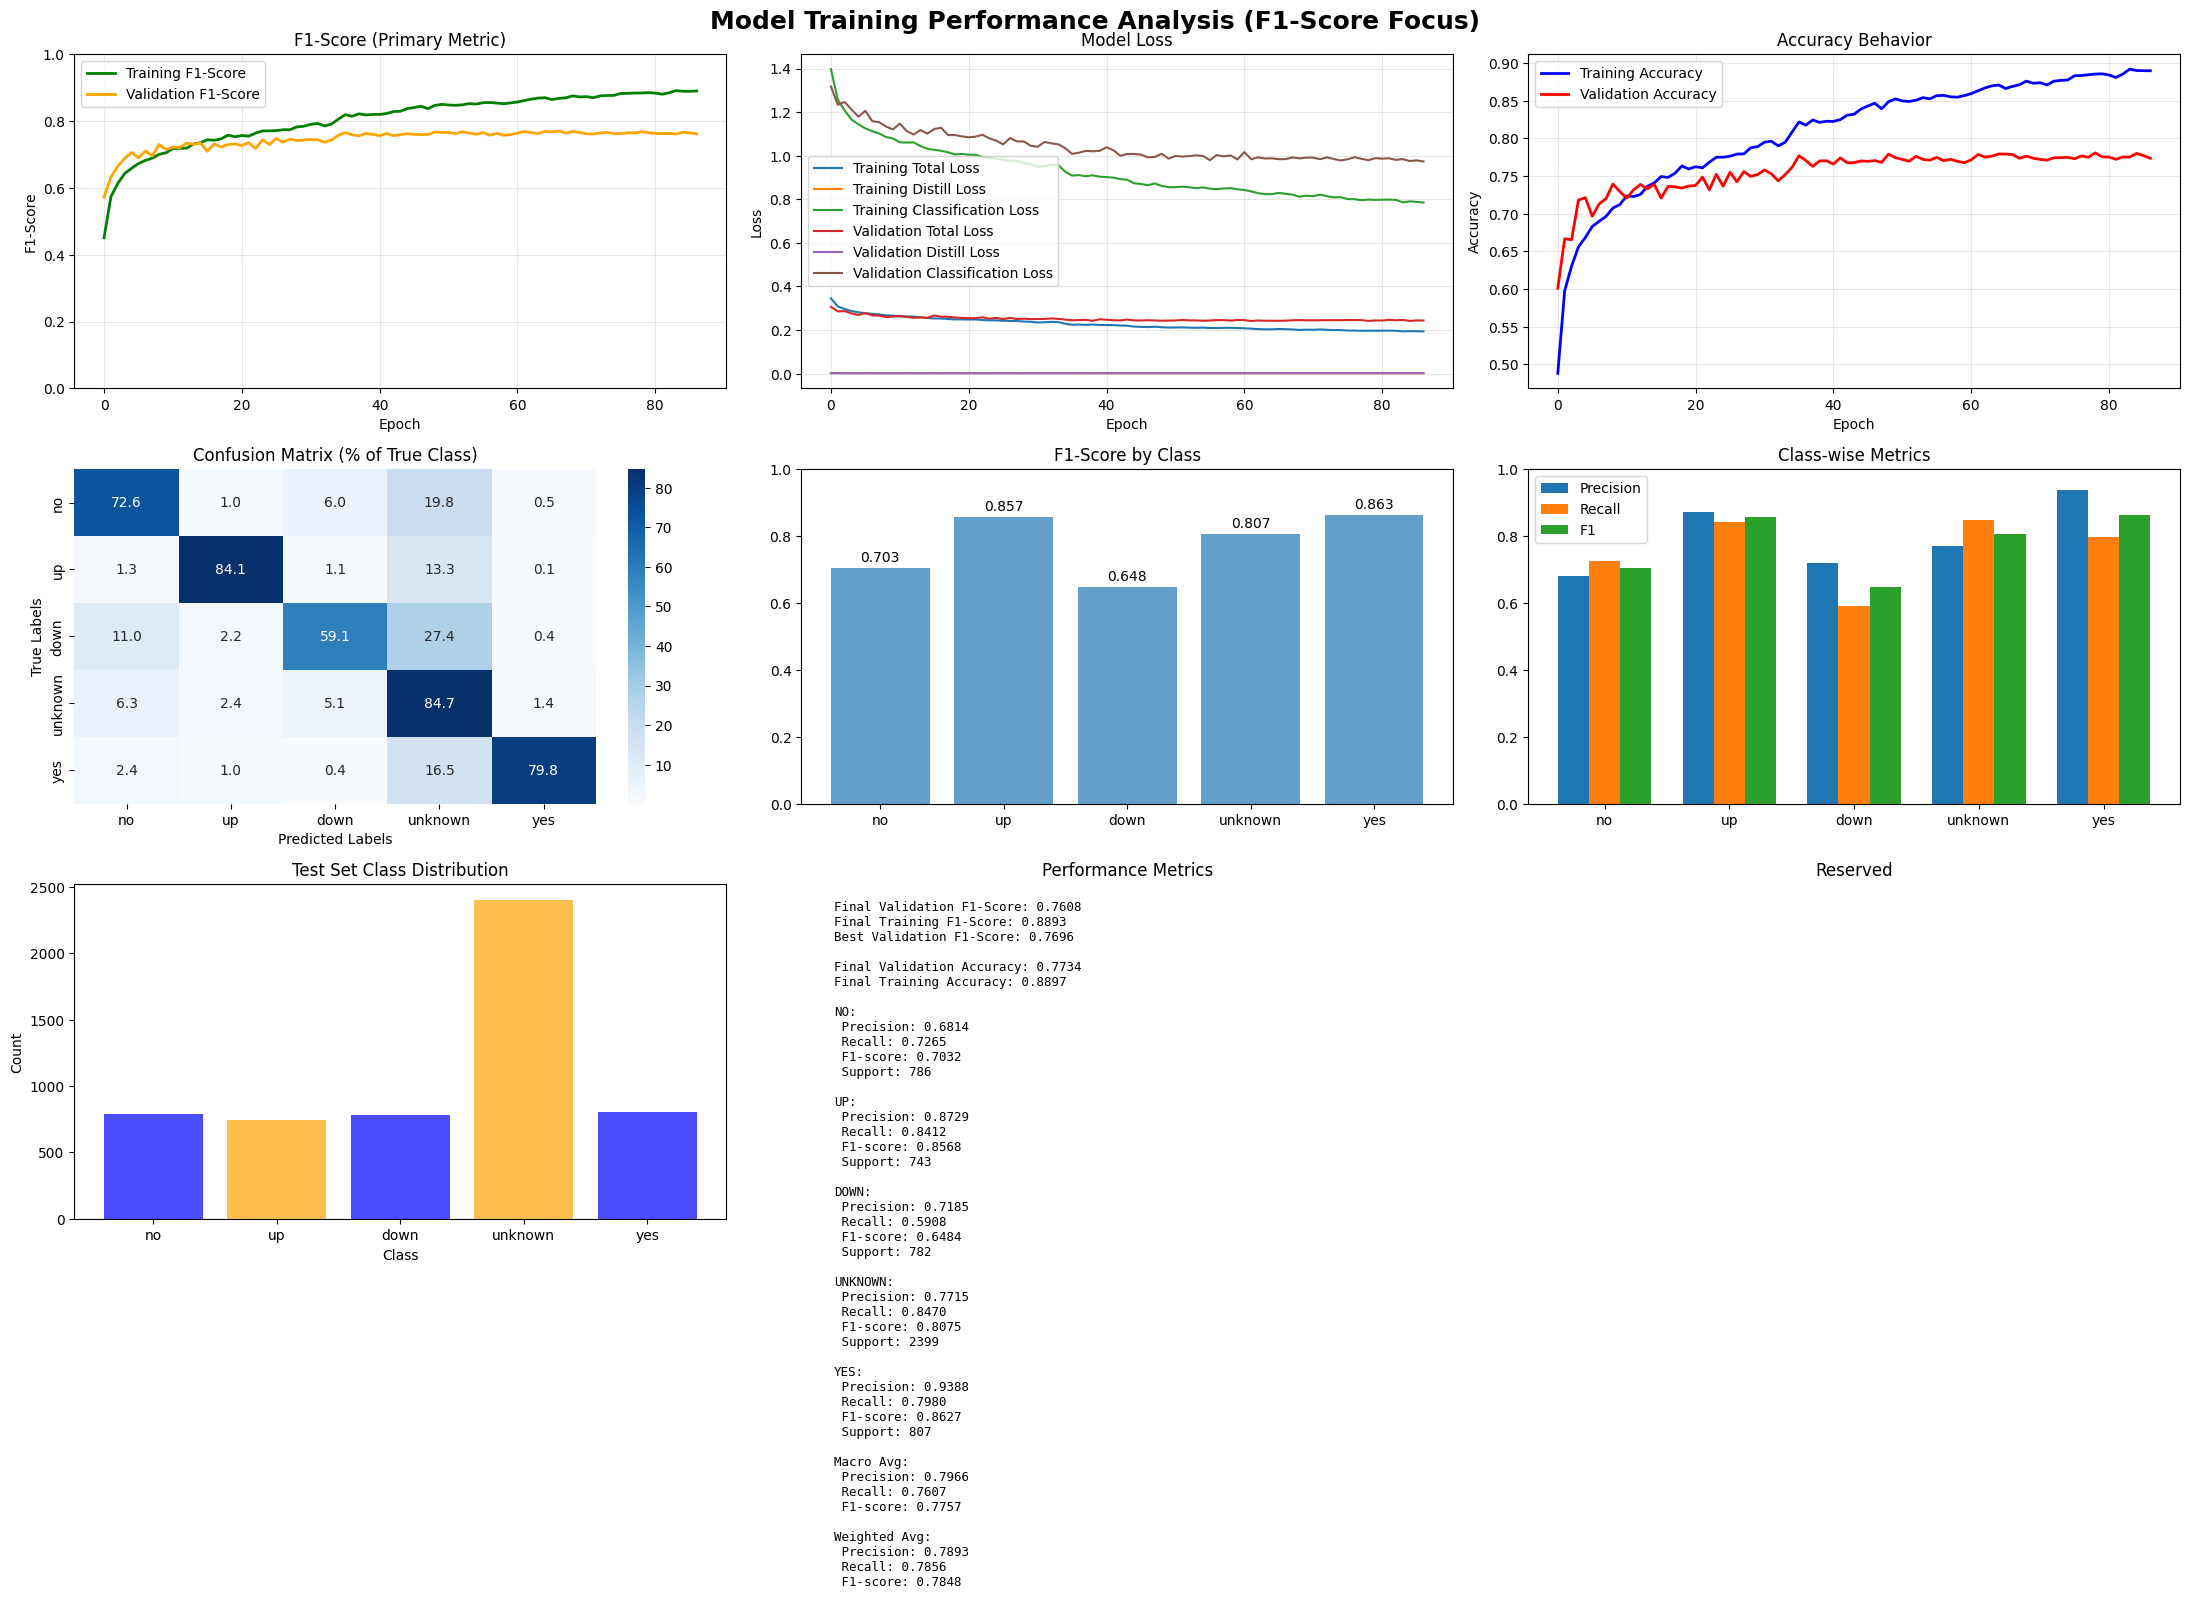

TRAINING SUMMARY (F1-Score Focus)
Total epochs trained: 87
Final training F1-score: 0.8893
Final validation F1-score: 0.7608
Best validation F1-score: 0.7696
Final training accuracy: 0.8897
Final validation accuracy: 0.7734
Final training loss: 0.1939
Final validation loss: 0.2437

Test Set Performance:
              precision    recall  f1-score   support

          no       0.68      0.73      0.70       786
          up       0.87      0.84      0.86       743
        down       0.72      0.59      0.65       782
     unknown       0.77      0.85      0.81      2399
         yes       0.94      0.80      0.86       807

    accuracy                           0.79      5517
   macro avg       0.80      0.76      0.78      5517
weighted avg       0.79      0.79      0.78      5517


Overall Weighted F1-Score on Test Set: 0.7848

Compressed model saved as compressed_dense_student.h5

COMPRESSION RESULTS
Final Test Results:
  Total Loss: 0.2413
  Distillation Loss: 0.0023
  Student Loss

In [3]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_curve, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

class F1Score(tf.keras.metrics.Metric):
    """
    Streaming multi-class F1 metric for sparse integer labels.
    average: "macro" or "weighted"
    """
    def __init__(self, num_classes, average="macro", name="f1_score", **kwargs):
        super().__init__(name=name, **kwargs)
        assert average in ("macro", "weighted")
        self.num_classes = num_classes
        self.average = average

        # Per-class accumulators (float because we'll sum confusion counts)
        self.tp = self.add_weight(name="tp", shape=(num_classes,), initializer="zeros")
        self.fp = self.add_weight(name="fp", shape=(num_classes,), initializer="zeros")
        self.fn = self.add_weight(name="fn", shape=(num_classes,), initializer="zeros")
        self.support = self.add_weight(name="support", shape=(num_classes,), initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        # y_true: (B,) int; y_pred: (B, C) logits
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)

        # Convert logits to probabilities for argmax
        y_pred_probs = tf.nn.softmax(y_pred, axis=1)

        # Use argmax for predicted class
        y_pred_labels = tf.argmax(y_pred_probs, axis=1, output_type=tf.int32)

        # Confusion matrix: shape (C, C)
        cm = tf.math.confusion_matrix(y_true, y_pred_labels, num_classes=self.num_classes, dtype=self.dtype)
        # Per-class counts
        tp = tf.linalg.diag_part(cm)
        fp = tf.reduce_sum(cm, axis=0) - tp
        fn = tf.reduce_sum(cm, axis=1) - tp
        support = tf.reduce_sum(cm, axis=1)

        self.tp.assign_add(tf.cast(tp, self.dtype))
        self.fp.assign_add(tf.cast(fp, self.dtype))
        self.fn.assign_add(tf.cast(fn, self.dtype))
        self.support.assign_add(tf.cast(support, self.dtype))

    def result(self):
        eps = tf.keras.backend.epsilon()
        precision = self.tp / (self.tp + self.fp + eps)
        recall = self.tp / (self.tp + self.fn + eps)
        f1_per_class = 2.0 * precision * recall / (precision + recall + eps)

        if self.average == "macro":
            return tf.reduce_mean(f1_per_class)
        else:  # "weighted"
            weights = self.support / (tf.reduce_sum(self.support) + eps)
            return tf.reduce_sum(f1_per_class * weights)

    def reset_state(self):
        for v in (self.tp, self.fp, self.fn, self.support):
            v.assign(tf.zeros_like(v))

# 7. Target Student Model - EXACTLY as you specified
def build_student_model(input_shape, num_classes=94):
    """Your exact target architecture - simple 3-layer dense network"""
    inputs = tf.keras.Input(shape=input_shape, name="input")  # Already flattened input (1600,)

    x = tf.keras.layers.Dense(256, activation="relu", name="dense_1")(inputs)
    x = tf.keras.layers.Dropout(0.3)(x)

    x = tf.keras.layers.Dense(256, activation="relu", name="dense_2")(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    x = tf.keras.layers.Dense(256, activation="relu", name="dense_3")(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    output = tf.keras.layers.Dense(num_classes, name="logits")(x)

    return tf.keras.Model(inputs, output, name="student_dnn")

def calculate_precision_recall_f1(y_true, y_pred, class_names):
    """Calculate precision, recall, and F1 for each class"""
    from sklearn.metrics import precision_recall_fscore_support

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0
    )

    results = {}
    for i, class_name in enumerate(class_names):
        results[class_name] = {
            'precision': precision[i],
            'recall': recall[i],
            'f1': f1[i],
            'support': support[i]
        }

    return results

def plot_training_performance(history, model, X_test, y_test, class_names, y_train=None, y_val=None, y_test_labels=None):
    """Create comprehensive graphs showing training performance with F1-score, accuracy, and sample counts"""

    # Get predictions
    y_pred_proba = model.predict(X_test)
    y_pred = np.argmax(y_pred_proba, axis=1)

    # Convert one-hot encoded y_test to class indices if needed
    if len(y_test.shape) > 1:
        y_true = np.argmax(y_test, axis=1)
    else:
        y_true = y_test

    # Calculate precision, recall, F1 for each class
    metrics = calculate_precision_recall_f1(y_true, y_pred, class_names)

    # Create figure with more subplots (3x3 grid now)
    fig, axes = plt.subplots(3, 3, figsize=(22, 16))
    fig.suptitle('Model Training Performance Analysis (F1-Score Focus)', fontsize=18, fontweight='bold')

    # 1. F1-Score plot
    if 'f1_score' in history.history:
        axes[0, 0].plot(history.history['f1_score'], label='Training F1-Score', linewidth=2, color='green')
        axes[0, 0].plot(history.history['val_f1_score'], label='Validation F1-Score', linewidth=2, color='orange')
        axes[0, 0].set_title('F1-Score (Primary Metric)')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('F1-Score')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        axes[0, 0].set_ylim(0, 1)

    # 2. Loss plot
    axes[0,1].plot(history.history['total_loss'], label="Training Total Loss")
    axes[0,1].plot(history.history['distill_loss'], label="Training Distill Loss")
    axes[0,1].plot(history.history['student_loss'], label="Training Classification Loss")
    axes[0,1].plot(history.history['val_total_loss'], label="Validation Total Loss")
    axes[0,1].plot(history.history['val_distill_loss'], label="Validation Distill Loss")
    axes[0,1].plot(history.history['val_student_loss'], label="Validation Classification Loss")
    axes[0, 1].set_title('Model Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Accuracy plot
    axes[0, 2].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2, color='blue')
    axes[0, 2].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='red')
    axes[0, 2].set_title('Accuracy Behavior')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Accuracy')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)

    # 4. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[1, 0])
    axes[1, 0].set_title('Confusion Matrix (% of True Class)')
    axes[1, 0].set_xlabel('Predicted Labels')
    axes[1, 0].set_ylabel('True Labels')

    # 5. F1-Score by class
    class_f1_scores = [metrics[c]['f1'] for c in class_names]
    bars = axes[1, 1].bar(range(len(class_names)), class_f1_scores, alpha=0.7)
    axes[1, 1].set_title('F1-Score by Class')
    axes[1, 1].set_ylim(0, 1)
    axes[1, 1].set_xticks(range(len(class_names)))
    axes[1, 1].set_xticklabels(class_names)
    for bar, value in zip(bars, class_f1_scores):
        axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                       f'{value:.3f}', ha='center', va='bottom')

    # 6. Precision-Recall-F1 grouped bars
    precision_values = [metrics[c]['precision'] for c in class_names]
    recall_values = [metrics[c]['recall'] for c in class_names]
    f1_values = [metrics[c]['f1'] for c in class_names]
    width = 0.25
    idx = np.arange(len(class_names))
    axes[1, 2].bar(idx - width, precision_values, width, label="Precision")
    axes[1, 2].bar(idx, recall_values, width, label="Recall")
    axes[1, 2].bar(idx + width, f1_values, width, label="F1")
    axes[1, 2].set_title('Class-wise Metrics')
    axes[1, 2].set_xticks(idx)
    axes[1, 2].set_xticklabels(class_names)
    axes[1, 2].legend()
    axes[1, 2].set_ylim(0, 1)

    # 7. Sample counts (stacked)
    unique, counts = np.unique(y_true, return_counts=True)
    axes[2, 0].bar(unique, counts, color=['blue', 'orange'], alpha=0.7)
    axes[2, 0].set_title('Test Set Class Distribution')
    axes[2, 0].set_xlabel('Class')
    axes[2, 0].set_ylabel('Count')
    axes[2, 0].set_xticks(unique)
    axes[2, 0].set_xticklabels(class_names)

    # 8. Text metrics summary
    metrics_text = ""
    if 'val_f1_score' in history.history:
        metrics_text += f"Final Validation F1-Score: {history.history['val_f1_score'][-1]:.4f}\n"
        metrics_text += f"Final Training F1-Score: {history.history['f1_score'][-1]:.4f}\n"
        metrics_text += f"Best Validation F1-Score: {max(history.history['val_f1_score']):.4f}\n\n"
    metrics_text += f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}\n"
    metrics_text += f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}\n\n"

    for c in class_names:
        metrics_text += f"{c.upper()}:\n"
        metrics_text += f" Precision: {metrics[c]['precision']:.4f}\n"
        metrics_text += f" Recall: {metrics[c]['recall']:.4f}\n"
        metrics_text += f" F1-score: {metrics[c]['f1']:.4f}\n"
        metrics_text += f" Support: {metrics[c]['support']}\n\n"

    # Macro/weighted
    macro_precision = np.mean([metrics[c]['precision'] for c in class_names])
    macro_recall = np.mean([metrics[c]['recall'] for c in class_names])
    macro_f1 = np.mean([metrics[c]['f1'] for c in class_names])
    total_support = sum([metrics[c]['support'] for c in class_names])
    weighted_precision = sum([metrics[c]['precision'] * metrics[c]['support'] for c in class_names]) / total_support
    weighted_recall = sum([metrics[c]['recall'] * metrics[c]['support'] for c in class_names]) / total_support
    weighted_f1 = sum([metrics[c]['f1'] * metrics[c]['support'] for c in class_names]) / total_support

    metrics_text += f"Macro Avg:\n Precision: {macro_precision:.4f}\n Recall: {macro_recall:.4f}\n F1-score: {macro_f1:.4f}\n\n"
    metrics_text += f"Weighted Avg:\n Precision: {weighted_precision:.4f}\n Recall: {weighted_recall:.4f}\n F1-score: {weighted_f1:.4f}"

    axes[2, 1].text(0.05, 0.95, metrics_text, transform=axes[2, 1].transAxes,
                    fontfamily='monospace', verticalalignment='top', fontsize=9)
    axes[2, 1].set_title('Performance Metrics')
    axes[2, 1].set_axis_off()

    # 9. Reserved slot
    axes[2, 2].axis("off")
    axes[2, 2].set_title("Reserved")

    plt.tight_layout()
    plt.show()

    # Print training summary with F1-score focus
    print("=" * 60)
    print("TRAINING SUMMARY (F1-Score Focus)")
    print("=" * 60)
    print(f"Total epochs trained: {len(history.history['total_loss'])}")
    if 'f1_score' in history.history:
        print(f"Final training F1-score: {history.history['f1_score'][-1]:.4f}")
        print(f"Final validation F1-score: {history.history['val_f1_score'][-1]:.4f}")
        print(f"Best validation F1-score: {max(history.history['val_f1_score']):.4f}")
    print(f"Final training accuracy: {history.history['accuracy'][-1]:.4f}")
    print(f"Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")
    print(f"Final training loss: {history.history['total_loss'][-1]:.4f}")
    print(f"Final validation loss: {history.history['val_total_loss'][-1]:.4f}")

    print("\nTest Set Performance:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Calculate and display overall F1-score
    overall_f1 = f1_score(y_true, y_pred, average='weighted')
    print(f"\nOverall Weighted F1-Score on Test Set: {overall_f1:.4f}")

    return fig

# 8. Knowledge Distillation for Complex-to-Simple Model Compression
class ModelCompressionDistiller(tf.keras.Model):
    """
    Distills complex sparse convolution model into simple dense network
    Teacher uses 2D input, student uses flattened input
    """
    def __init__(self, student, teacher, num_classes, alpha=0.8, temperature=5.0, f1_average="macro"):
        super().__init__()
        self.student = student
        self.teacher = teacher
        self.alpha = alpha  # Higher weight for distillation (complex->simple needs more guidance)
        self.temperature = temperature  # Higher temperature for better knowledge transfer

        # Metrics
        self.distillation_loss_tracker = tf.keras.metrics.Mean(name="distill_loss")
        self.student_loss_tracker = tf.keras.metrics.Mean(name="student_loss")
        self.student_accuracy_tracker = tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")
        self.student_f1_tracker = F1Score(num_classes=num_classes, average=f1_average, name="f1_score")
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.distillation_loss_tracker,
            self.student_loss_tracker,
            self.student_accuracy_tracker,
            self.student_f1_tracker
        ]

    def compile(self, optimizer, class_weights=None, **kwargs):
        super().compile(**kwargs)
        self.optimizer = optimizer
        self.student_loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
        self.distillation_loss_fn = tf.keras.losses.KLDivergence()
        self.class_weights = class_weights  # Store class weights
    def train_step(self, data):
        x_2d, y = data  # Teacher gets 2D input, student gets flattened
        x_flat = tf.reshape(x_2d, (tf.shape(x_2d)[0], -1))  # Flatten for student

        with tf.GradientTape() as tape:
            # Get predictions from both models
            teacher_predictions = self.teacher(x_2d, training=False)
            student_logits = self.student(x_flat, training=True)  # Student outputs logits

            # Apply temperature scaling for knowledge distillation
            teacher_soft = tf.nn.softmax(teacher_predictions / self.temperature)
            student_soft = tf.nn.softmax(student_logits / self.temperature)

            # Calculate losses
            distillation_loss = self.distillation_loss_fn(teacher_soft, student_soft)
            if self.class_weights is not None:
                sample_weights = tf.gather(self.class_weights, y)
                student_loss = self.student_loss_fn(y, student_logits, sample_weight=sample_weights)
            else:
                student_loss = self.student_loss_fn(y, student_logits)

            total_loss = (
                self.alpha * distillation_loss * (self.temperature ** 2) +
                (1 - self.alpha) * student_loss
            )

        # Update student model
        gradients = tape.gradient(total_loss, self.student.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.student.trainable_variables))

        # Update metrics - convert logits to probabilities for accuracy and F1
        student_probs = tf.nn.softmax(student_logits, axis=1)
        self.total_loss_tracker.update_state(total_loss)
        self.distillation_loss_tracker.update_state(distillation_loss)
        self.student_loss_tracker.update_state(student_loss)
        self.student_accuracy_tracker.update_state(y, student_probs)  # Use probabilities
        self.student_f1_tracker.update_state(y, student_logits)  # F1Score handles conversion internally

        return {
            "total_loss": self.total_loss_tracker.result(),
            "distill_loss": self.distillation_loss_tracker.result(),
            "student_loss": self.student_loss_tracker.result(),
            "accuracy": self.student_accuracy_tracker.result(),
            "f1_score": self.student_f1_tracker.result()
        }

    def test_step(self, data):
        x_2d, y = data  # Teacher gets 2D input, student gets flattened
        x_flat = tf.reshape(x_2d, (tf.shape(x_2d)[0], -1))  # Flatten for student

        teacher_predictions = self.teacher(x_2d, training=False)
        student_logits = self.student(x_flat, training=False)  # Student outputs logits

        teacher_soft = tf.nn.softmax(teacher_predictions / self.temperature)
        student_soft = tf.nn.softmax(student_logits / self.temperature)

        distillation_loss = self.distillation_loss_fn(teacher_soft, student_soft)
        student_loss = self.student_loss_fn(y, student_logits)  # Use logits directly
        total_loss = (
            self.alpha * distillation_loss * (self.temperature ** 2) +
            (1 - self.alpha) * student_loss
        )

        # Update metrics - convert logits to probabilities for accuracy
        student_probs = tf.nn.softmax(student_logits, axis=1)
        self.total_loss_tracker.update_state(total_loss)
        self.distillation_loss_tracker.update_state(distillation_loss)
        self.student_loss_tracker.update_state(student_loss)
        self.student_accuracy_tracker.update_state(y, student_probs)  # Use probabilities
        self.student_f1_tracker.update_state(y, student_logits)  # F1Score handles conversion internally

        return {
            "total_loss": self.total_loss_tracker.result(),
            "distill_loss": self.distillation_loss_tracker.result(),
            "student_loss": self.student_loss_tracker.result(),
            "accuracy": self.student_accuracy_tracker.result(),
            "f1_score": self.student_f1_tracker.result()
        }

# 9. Data preparation - teacher gets 2D input, student gets flattened
def create_distillation_data(X_2d, y, batch_size=32, shuffle=True):
    """Create dataset - teacher gets 2D input, student gets flattened input"""
    dataset = tf.data.Dataset.from_tensor_slices((X_2d, y))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000, seed=seed)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

def add_softmax_to_student(student_model):
    """Add softmax activation to the trained student model for inference"""
    inputs = student_model.input
    logits = student_model.output
    softmax_output = tf.keras.layers.Activation("softmax", name="output_softmax")(logits)

    return tf.keras.Model(inputs, softmax_output, name="student_dnn_with_softmax")

# 10. Build student model
input_shape = (1600,)  # Flattened input shape for student
num_classes = n_classes

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
class_weights_tensor = tf.constant(list(class_weight_dict.values()), dtype=tf.float32)
student_model = build_student_model(input_shape, num_classes)
print("\nStudent Model (Target Simple Dense Network):")
student_model.summary()

# 11. Initialize distiller with parameters optimized for complex->simple compression
distiller = ModelCompressionDistiller(
    student=student_model,
    teacher=teacher_dvec_model,
    alpha=0.8,  # Emphasize distillation for complex->simple transfer
    temperature=5.0,  # Higher temperature for better knowledge transfer
    num_classes=n_classes,
    f1_average="macro"
)

distiller.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-3),  # Slightly higher LR for simple model
    class_weights=class_weights_tensor
)

# 12. Create datasets - teacher gets 2D input
train_data = create_distillation_data(X_train, y_train, batch_size=32)
val_data = create_distillation_data(X_val, y_val, batch_size=32)
test_data = create_distillation_data(X_test, y_test, batch_size=32)
# 13. Callbacks optimized for compression task
class StudentCheckpoint(tf.keras.callbacks.Callback):
  def __init__(self, path, monitor="val_f1_score", mode="max"):
    super().__init__()
    self.path=path
    self.monitor=monitor
    self.mode=mode
    self.best=-np.inf if mode=='max' else np.inf

  def on_epoch_end(self, epochs, logs=None):
    current=logs.get(self.monitor)
    if current is None:
      if(self.mode=="max" and current>self.best) or (self.mode=="min" and current<self.best):
        print(f"\nEpoch {epochs+1}: {self.monitor} improved from {self.best:.4f} to {current:.4f}, saving to {self.path}")
        self.best=current
        self.model.student.save_weights(self.path)

BEST_FILE="best_compressed_student.h5"
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_f1_score",
        mode='max',
        factor=0.7,
        patience=8,
        verbose=1,
        min_lr=1e-5
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_f1_score",
        mode='max',
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    StudentCheckpoint(
        path=BEST_FILE,
        monitor="val_f1_score",
        mode='max'
    )
]

# 14. Train the compression
print("\n" + "="*60)
print("COMPRESSING COMPLEX MODEL TO SIMPLE DENSE NETWORK")
print("="*60)
print(f"Teacher: Sparse Conv Model ({teacher_dvec_model.count_params():,} params)")
print(f"Student: Simple Dense Model ({student_model.count_params():,} params)")
print(f"Compression Ratio: {teacher_dvec_model.count_params() / student_model.count_params():.1f}x")
print("="*60)

history = distiller.fit(
    train_data,
    validation_data=val_data,
    epochs=100,
    callbacks=callbacks,
    verbose=1
)

if os.path.exists(BEST_FILE):
  print("\nRestoring best student weights")
  distiller.student.load_weights(BEST_FILE)

student_model=add_softmax_to_student(student_model)
plot_training_performance(history, distiller.student, X_test.reshape(X_test.shape[0], -1), y_test, class_names, y_test_labels=class_names)
# 15. Save the compressed model
model_name = "compressed_dense_student"
student_model.save(f"{model_name}.h5")
print(f"\nCompressed model saved as {model_name}.h5")

# 17. Comprehensive evaluation
print("\n" + "="*60)
print("COMPRESSION RESULTS")
print("="*60)

# Evaluate on test set
test_data = create_distillation_data(X_test, y_test, batch_size=32, shuffle=False)
test_results = distiller.evaluate(test_data, verbose=0)

print(f"Final Test Results:")
print(f"  Total Loss: {test_results[0]:.4f}")
print(f"  Distillation Loss: {test_results[1]:.4f}")
print(f"  Student Loss: {test_results[2]:.4f}")
print(f"  Student Accuracy: {test_results[3]:.4f}")

# 18. Compare teacher vs compressed student
print(f"\nPerformance Comparison (1000 test samples):")
teacher_pred = teacher_dvec_model.predict(X_test, verbose=0)
student_pred = student_model.predict(X_test.reshape(X_test.shape[0], -1), verbose=0)

teacher_acc = np.mean(np.argmax(teacher_pred, axis=1) == y_test)
student_acc = np.mean(np.argmax(student_pred, axis=1) == y_test)

print(f"  Teacher (Complex) Accuracy: {teacher_acc:.4f}")
print(f"  Student (Simple) Accuracy: {student_acc:.4f}")
print(f"  Performance Retention: {(student_acc/teacher_acc)*100:.1f}%")

# 19. Architecture comparison
print(f"\nArchitecture Comparison:")
print(f"  Teacher: Sparse Conv + SoftMax Pooling + Dense (2D input)")
print(f"  Student: Simple 3-Layer Dense Network (flattened input)")
print(f"  Parameter Reduction: {((teacher_dvec_model.count_params() - student_model.count_params()) / teacher_dvec_model.count_params()) * 100:.1f}%")

# 20. Model size analysis
def get_model_size(model_path):
    return os.path.getsize(model_path) / (1024 * 1024)

student_size = get_model_size(f"{model_name}.h5")

print(f"\nModel Size:")
print(f"  Compressed Student (.h5): {student_size:.2f} MB")

print("\n" + "="*60)
print("MODEL COMPRESSION COMPLETED SUCCESSFULLY!")
print("Complex sparse convolution model compressed to simple 3-layer dense network")
print("="*60)